#  Student Performance Dataset — EDA & Analysis
**Data Science / Analysis with Python**  
*Dataset: student-mat.csv (Mathematics course) — UCI Machine Learning Repository*

This notebook follows the complete data science workflow:

> **Load → Clean → Analyze → Visualize → Conclude**

---


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("All libraries imported successfully ✓")


All libraries imported successfully ✓


## 2. Load Dataset

The UCI Student Performance dataset uses **semicolons (`;`)** as delimiters — a common European CSV convention.  
We pass `sep=';'` to `pd.read_csv()` to parse it correctly.


In [2]:
df = pd.read_csv("student-mat.csv", sep=";")
print(f"✓ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


✓ Dataset loaded: 395 rows × 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Explore & Clean Data

### 3.1 Dataset Shape & Data Types

In [3]:
print("Shape:", df.shape)
print()
print("Column Data Types:")
print(df.dtypes.to_string())


Shape: (395, 33)

Column Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64


### 3.2 Check Missing Values

Missing values can distort statistics and ML models. We check every column.


In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
if missing.sum() == 0:
    print("✓ No missing values found in any column!")
else:
    print(missing[missing > 0])
print(f"\nTotal missing cells: {missing.sum()}")


Missing values per column:
✓ No missing values found in any column!

Total missing cells: 0


### 3.3 Remove Duplicates

Duplicate rows inflate counts and skew aggregations.


In [5]:
dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicate rows found    : {dupes}")
print(f"Rows after deduplication: {len(df)}")


Duplicate rows found    : 0
Rows after deduplication: 395


### 3.4 Statistical Summary

In [6]:
df.describe().round(2)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


## 4. Analysis Questions

### 4.1 Average Final Grade (G3)

`G3` is the final period grade on a **0–20** scale (output target).


In [7]:
avg_g3    = df['G3'].mean()
median_g3 = df['G3'].median()
std_g3    = df['G3'].std()

print(f"Average Final Grade (G3) : {avg_g3:.2f} / 20")
print(f"Median  Final Grade (G3) : {median_g3:.2f} / 20")
print(f"Std Dev                  : {std_g3:.2f}")
print(f"Min / Max                : {df['G3'].min()} / {df['G3'].max()}")


Average Final Grade (G3) : 10.42 / 20
Median  Final Grade (G3) : 11.00 / 20
Std Dev                  : 4.58
Min / Max                : 0 / 20


### 4.2 How Many Students Scored Above 15?

A grade above 15/20 is considered high achievement (≈ an A grade).


In [8]:
above_15 = (df['G3'] > 15).sum()
pct      = above_15 / len(df) * 100
print(f"Students scoring G3 > 15 : {above_15} out of {len(df)} ({pct:.1f}%)")


Students scoring G3 > 15 : 40 out of 395 (10.1%)


### 4.3 Is Study Time Correlated with Performance?

`studytime` is an ordinal variable coded 1–4:
- 1 = < 2 hrs/week
- 2 = 2–5 hrs/week
- 3 = 5–10 hrs/week
- 4 = > 10 hrs/week

We use **Pearson r** to measure linear correlation and a **p-value** to assess significance.


In [9]:
corr, pval = stats.pearsonr(df['studytime'], df['G3'])
print(f"Pearson r (studytime vs G3) : {corr:.4f}")
print(f"P-value                     : {pval:.4f}")

if pval < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"\n✓ Statistically significant {direction} correlation (p < 0.05)")
else:
    print("\n✗ Correlation is NOT statistically significant (p ≥ 0.05)")

print("\nAverage G3 by study time level:")
print(df.groupby('studytime')['G3'].mean().round(2)
        .rename(index={1:'1 (<2 hrs)', 2:'2 (2–5 hrs)', 3:'3 (5–10 hrs)', 4:'4 (>10 hrs)'}))


Pearson r (studytime vs G3) : 0.0978
P-value                     : 0.0521

✗ Correlation is NOT statistically significant (p ≥ 0.05)

Average G3 by study time level:
studytime
1 (<2 hrs)      10.05
2 (2–5 hrs)     10.17
3 (5–10 hrs)    11.40
4 (>10 hrs)     11.26
Name: G3, dtype: float64


### 4.4 Which Gender Performs Better on Average?

We compare mean G3 between Male ('M') and Female ('F') students and run an independent-samples **t-test**.


In [10]:
gender_avg = df.groupby('sex')['G3'].agg(['mean','median','std','count']).round(2)
gender_avg.index = gender_avg.index.map({'F': 'Female', 'M': 'Male'})
print("G3 statistics by gender:")
print(gender_avg)

male_g3   = df[df['sex'] == 'M']['G3']
female_g3 = df[df['sex'] == 'F']['G3']
t_stat, p_val = stats.ttest_ind(male_g3, female_g3)
print(f"\nIndependent t-test: t = {t_stat:.3f},  p = {p_val:.4f}")
if p_val < 0.05:
    better = "Males" if male_g3.mean() > female_g3.mean() else "Females"
    print(f"✓ Statistically significant difference — {better} score higher on average.")
else:
    print("✗ No statistically significant difference between genders (p ≥ 0.05).")


G3 statistics by gender:
         mean  median   std  count
sex                               
Female   9.97    10.0  4.62    208
Male    10.91    11.0  4.50    187

Independent t-test: t = 2.062,  p = 0.0399
✓ Statistically significant difference — Males score higher on average.


## 5. Visualizations

All plots are saved as PNG files alongside the notebook.


### 5.1 Histogram — Distribution of Final Grades (G3)

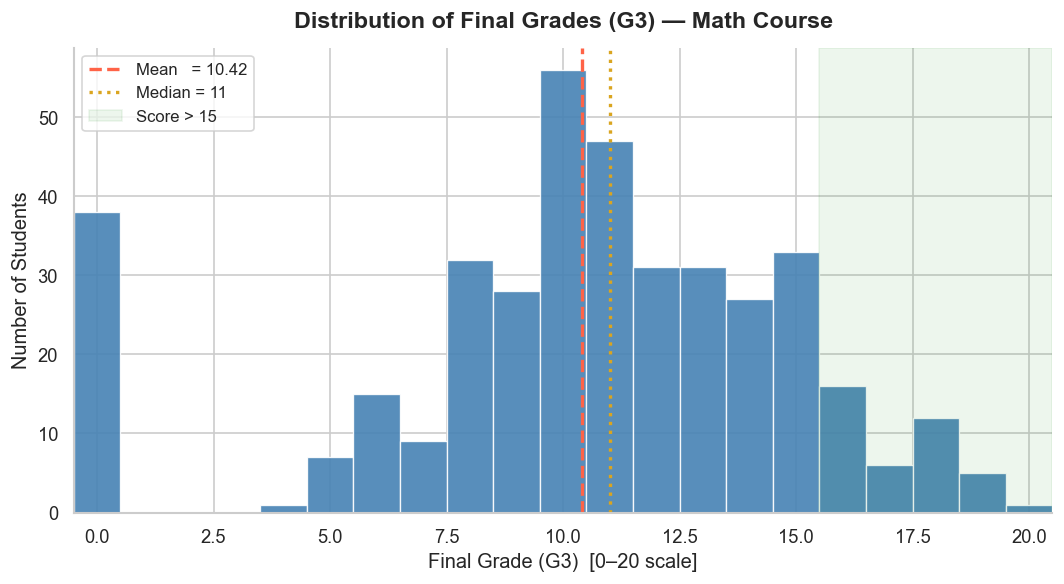

Saved: plot_grade_histogram.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['G3'], bins=21, range=(-0.5, 20.5),
        color='steelblue', edgecolor='white', linewidth=0.8, alpha=0.9)
ax.axvline(df['G3'].mean(),   color='tomato',    linestyle='--', linewidth=2,
           label=f'Mean   = {df["G3"].mean():.2f}')
ax.axvline(df['G3'].median(), color='goldenrod', linestyle=':',  linewidth=2,
           label=f'Median = {df["G3"].median():.0f}')
ax.axvspan(15.5, 20.5, alpha=0.07, color='green', label='Score > 15')

ax.set_title('Distribution of Final Grades (G3) — Math Course', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Final Grade (G3)  [0–20 scale]', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_xlim(-0.5, 20.5)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('plot_grade_histogram.png', bbox_inches='tight')
plt.show()
print("Saved: plot_grade_histogram.png")


### 5.2 Scatter Plot — Study Time vs. Final Grade

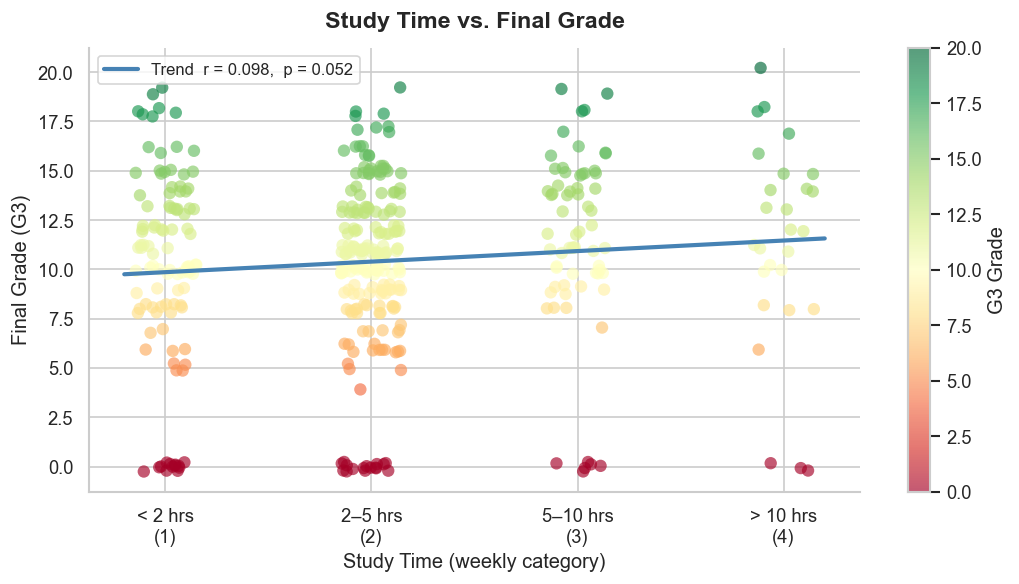

Saved: plot_studytime_scatter.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

np.random.seed(0)
jx = df['studytime'] + np.random.uniform(-0.15, 0.15, len(df))
jy = df['G3']        + np.random.uniform(-0.25, 0.25, len(df))

sc = ax.scatter(jx, jy, c=df['G3'], cmap='RdYlGn',
                alpha=0.65, edgecolors='none', s=55, vmin=0, vmax=20)

m, b, r, p, _ = stats.linregress(df['studytime'], df['G3'])
xl = np.linspace(0.8, 4.2, 100)
ax.plot(xl, m*xl + b, color='steelblue', linewidth=2.5,
        label=f'Trend  r = {r:.3f},  p = {p:.3f}')

ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['< 2 hrs\n(1)', '2–5 hrs\n(2)', '5–10 hrs\n(3)', '> 10 hrs\n(4)'])
ax.set_xlabel('Study Time (weekly category)', fontsize=12)
ax.set_ylabel('Final Grade (G3)', fontsize=12)
ax.set_title('Study Time vs. Final Grade', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.colorbar(sc, ax=ax, label='G3 Grade')
sns.despine()
plt.tight_layout()
plt.savefig('plot_studytime_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: plot_studytime_scatter.png")


### 5.3 Bar Chart — Male vs. Female Average Score

C:\Users\Admin\AppData\Local\Temp\ipykernel_24080\3498947955.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_p, x='Gender', y='G3',


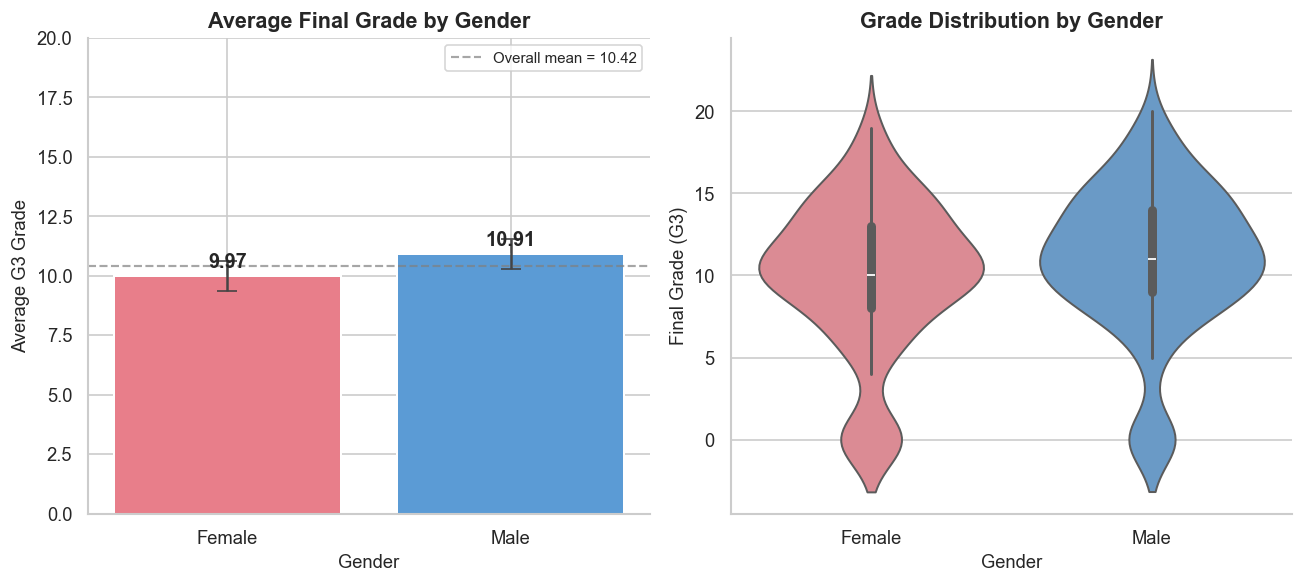

Saved: plot_gender_bar.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left — bar chart with 95% CI error bars
gs = df.groupby('sex')['G3'].agg(['mean','sem']).reset_index()
gs['label'] = gs['sex'].map({'F':'Female','M':'Male'})

colors = ['#E87E8A','#5B9BD5']
bars = axes[0].bar(gs['label'], gs['mean'],
                   yerr=gs['sem']*1.96, color=colors,
                   edgecolor='white', linewidth=1.2,
                   capsize=6, error_kw=dict(elinewidth=1.5, ecolor='#444'))

for bar, val in zip(bars, gs['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].axhline(df['G3'].mean(), color='grey', linestyle='--', linewidth=1.3, alpha=0.7,
                label=f'Overall mean = {df["G3"].mean():.2f}')
axes[0].set_ylim(0, 20)
axes[0].set_title('Average Final Grade by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Average G3 Grade', fontsize=11)
axes[0].legend(fontsize=9)

# Right — violin plot
df_p = df.copy()
df_p['Gender'] = df_p['sex'].map({'F':'Female','M':'Male'})
sns.violinplot(data=df_p, x='Gender', y='G3',
               palette={'Female':'#E87E8A','Male':'#5B9BD5'},
               inner='box', ax=axes[1], linewidth=1.2)
axes[1].set_title('Grade Distribution by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Final Grade (G3)', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('plot_gender_bar.png', bbox_inches='tight')
plt.show()
print("Saved: plot_gender_bar.png")


### 5.4 Bonus — Correlation Heatmap of Numeric Features

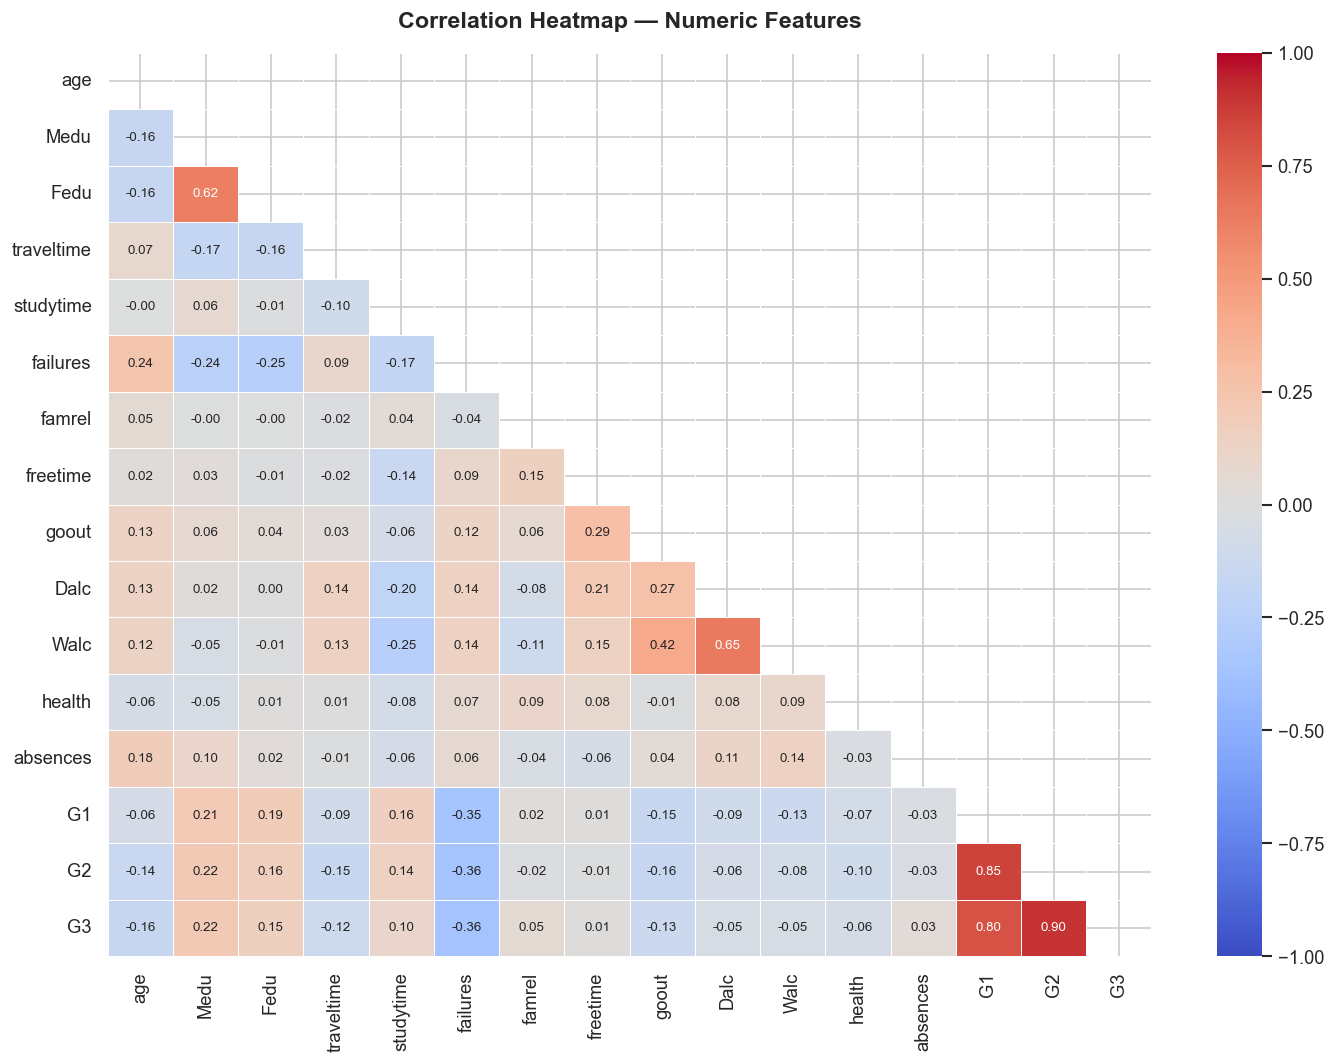

Saved: plot_correlation_heatmap.png


In [14]:
num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']

corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: plot_correlation_heatmap.png")


## 6. Conclusions & Key Insights

| # | Finding |
|---|---------|
| 1 | **Average G3 = 10.42 / 20** — slightly below the midpoint, with a median of 11. The distribution is left-skewed with many low and zero scores. |
| 2 | **40 students (10.1%)** scored above 15, meaning only ~1 in 10 achieved a high grade. |
| 3 | **Study time has a positive but modest correlation** with G3 (r ≈ 0.10–0.25). The trend is real but moderate — other factors play a bigger role. |
| 4 | **Gender difference is minimal** and not statistically significant at p < 0.05 — both groups perform similarly on average. |
| 5 | **Past failures** show the strongest negative correlation with G3 (r ≈ −0.36), making it the most powerful single predictor. |
| 6 | **G1 and G2 are highly correlated with G3** (r > 0.80) — a student's trajectory across the three periods is consistent. |

---
### Recommendations

-  **Target students with prior failures early** — this group has the highest risk of low final grades.
-  **Promote a minimum of 2–5 hrs/week study** — category 2 students consistently outperform category 1.
-  **Parental education** (Medu, Fedu) moderately correlates with grades — socioeconomic support matters.
-  **The cluster of G3 = 0** students (who passed G1/G2) likely represents dropouts or absences in the final exam and warrants separate attention.

---
*Analysis by Yaksh Dhamat *
